<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Histogram**


Estimated time needed: **45** minutes


In this lab, you will focus on the visualization of data. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


In this lab, you will perform the following:


- Visualize the distribution of data using histograms.

- Visualize relationships between features.

- Explore data composition and comparisons.


## Demo: Working with database


#### Download the database file.


In [1]:
!wget -O survey-data.sqlite https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite

'wget' is not recognized as an internal or external command,
operable program or batch file.


#### Install the required libraries and import them


In [2]:
!pip install pandas

In [3]:
!pip install matplotlib

In [4]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

#### Connect to the SQLite database


In [5]:
conn = sqlite3.connect('survey-data.sqlite')

## Demo: Basic SQL queries

**Demo 1: Count the number of rows in the table**


In [6]:
QUERY = "SELECT COUNT(*) FROM main"
df = pd.read_sql_query(QUERY, conn)
print(df)


   COUNT(*)
0     65437


**Demo 2: List all tables**


In [7]:
QUERY = """
SELECT name as Table_Name 
FROM sqlite_master 
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


,Table_Name
0,main


**Demo 3: Group data by age**


In [8]:
QUERY = """
SELECT Age, COUNT(*) as count 
FROM main 
GROUP BY Age 
ORDER BY Age
"""
df_age = pd.read_sql_query(QUERY, conn)
print(df_age)


                  Age  count
0     18-24 years old  14098
1     25-34 years old  23911
2     35-44 years old  14942
3     45-54 years old   6249
4     55-64 years old   2575
5   65 years or older    772
6   Prefer not to say    322
7  Under 18 years old   2568


## Hands-on Lab: Visualizing Data with Histograms


### 1. Visualizing the distribution of data (Histograms)


**1.1 Histogram of `CompTotal` (Total Compensation)**


Objective: Plot a histogram of `CompTotal` to visualize the distribution of respondents' total compensation.


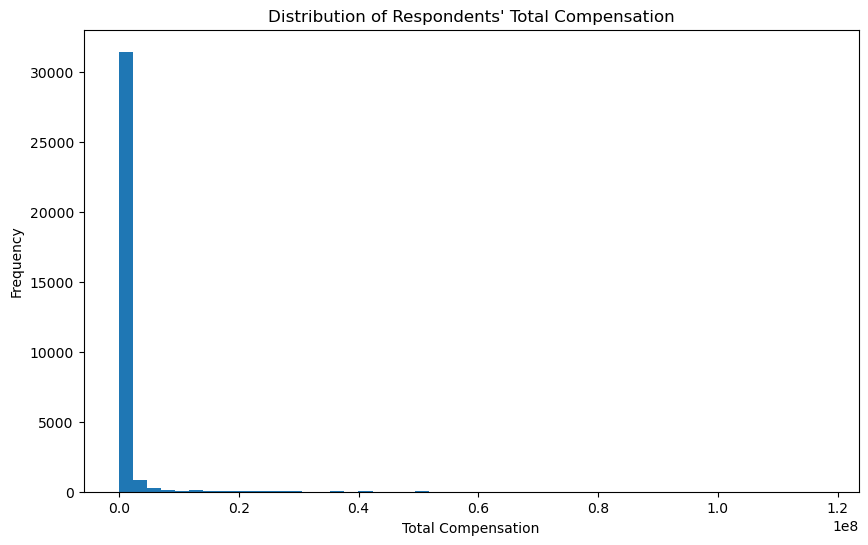

In [12]:
df = pd.read_csv("survey-data.csv")

df['CompTotal'] = pd.to_numeric(df['CompTotal'], errors='coerce')
comp_total = df['CompTotal'].dropna()

# Remove extreme outliers
upper_limit = comp_total.quantile(0.99)
comp_total_filtered = comp_total[comp_total <= upper_limit]

plt.figure(figsize=(10, 6))

plt.hist(comp_total_filtered, bins=50)

plt.title("Distribution of Respondents' Total Compensation")
plt.xlabel("Total Compensation")
plt.ylabel("Frequency")

plt.show()

**1.2 Histogram of YearsCodePro (Years of Professional Coding Experience)**


Objective: Plot a histogram of `YearsCodePro` to analyze the distribution of coding experience among respondents.


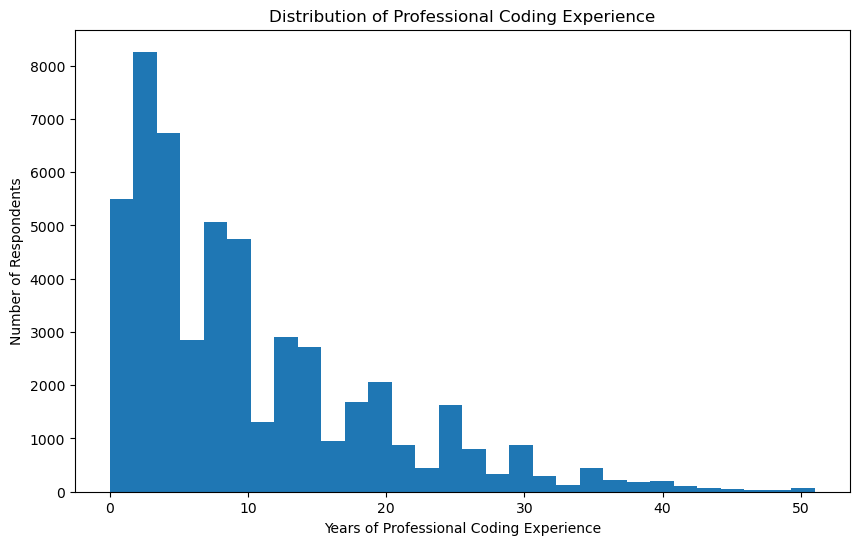

In [14]:
# Check unique values first
#df['YearsCodePro'].unique()

# Convert YearsCodePro to numeric
df['YearsCodePro_Numeric'] = df['YearsCodePro'].replace({
    'Less than 1 year': 0,
    'More than 50 years': 51
})

df['YearsCodePro_Numeric'] = pd.to_numeric(
    df['YearsCodePro_Numeric'],
    errors='coerce'
)

# Remove missing values
years_code_pro = df['YearsCodePro_Numeric'].dropna()

# Plot histogram
plt.figure(figsize=(10, 6))

plt.hist(years_code_pro, bins=30)

plt.title('Distribution of Professional Coding Experience')
plt.xlabel('Years of Professional Coding Experience')
plt.ylabel('Number of Respondents')

plt.show()

### 2. Visualizing Relationships in Data


**2.1 Histogram Comparison of `CompTotal` by `Age` Group**


Objective: Use histograms to compare the distribution of CompTotal across different Age groups.


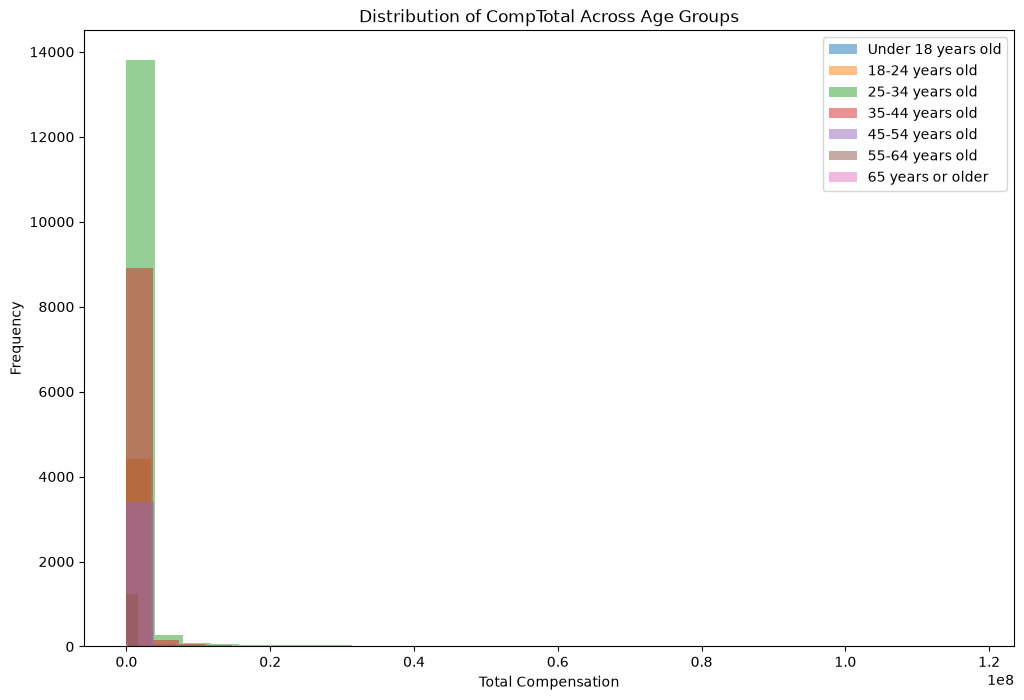

In [13]:
# Convert CompTotal to numeric
df['CompTotal'] = pd.to_numeric(df['CompTotal'], errors='coerce')

# Remove missing values
df_comp = df[['Age', 'CompTotal']].dropna()

# Remove extreme outliers using 99th percentile
upper_limit = df_comp['CompTotal'].quantile(0.99)
df_comp = df_comp[df_comp['CompTotal'] <= upper_limit]

# Define age group order
age_order = [
    'Under 18 years old',
    '18-24 years old',
    '25-34 years old',
    '35-44 years old',
    '45-54 years old',
    '55-64 years old',
    '65 years or older'
]

plt.figure(figsize=(12, 8))

for age_group in age_order:
    age_data = df_comp[df_comp['Age'] == age_group]['CompTotal']
    
    if len(age_data) > 0:
        plt.hist(
            age_data,
            bins=30,
            alpha=0.5,
            label=age_group
        )

plt.title('Distribution of CompTotal Across Age Groups')
plt.xlabel('Total Compensation')
plt.ylabel('Frequency')
plt.legend()
plt.show()

**2.2 Histogram of TimeSearching for Different Age Groups**


Objective: Use histograms to explore the distribution of `TimeSearching` (time spent searching for information) for respondents across different age groups.


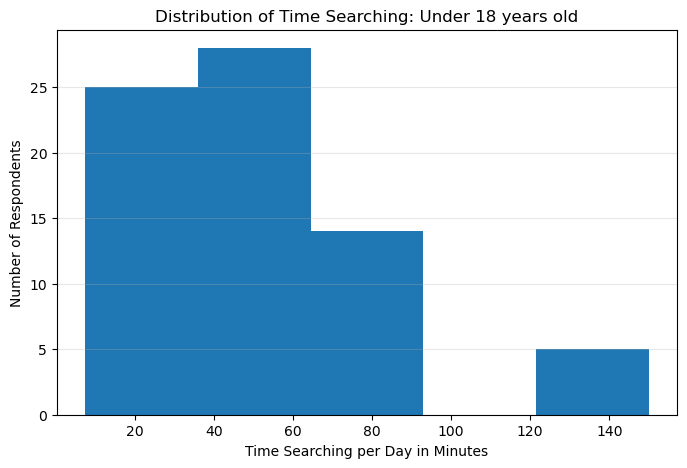

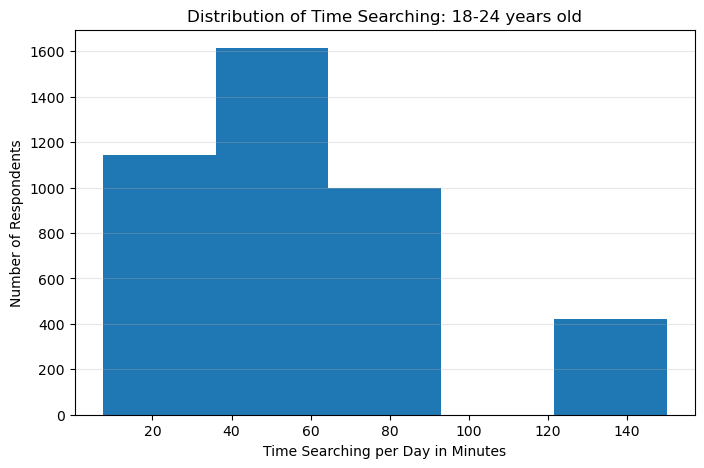

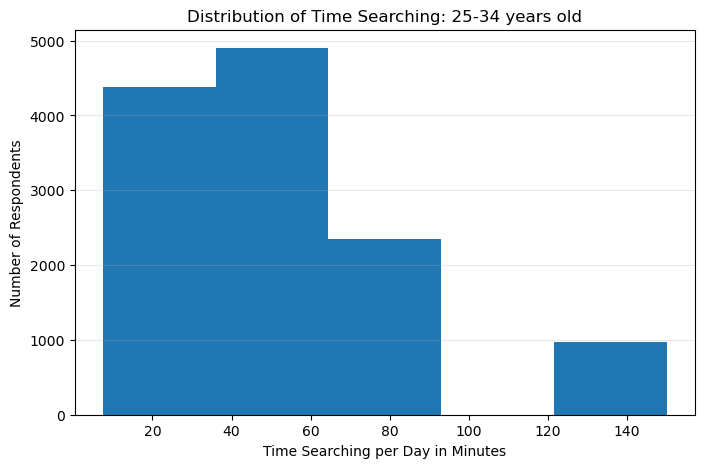

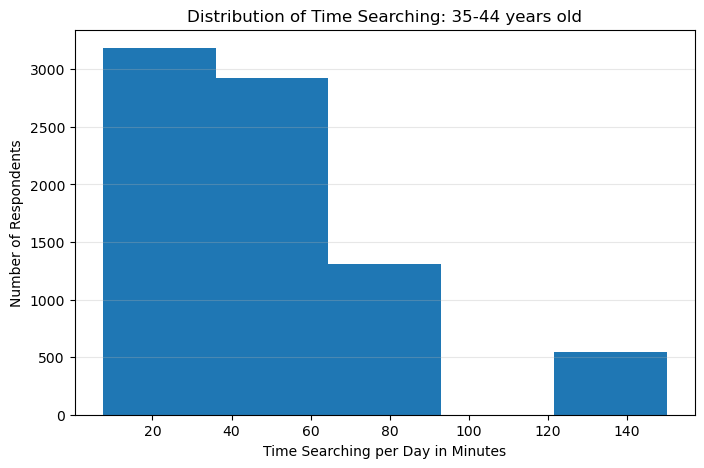

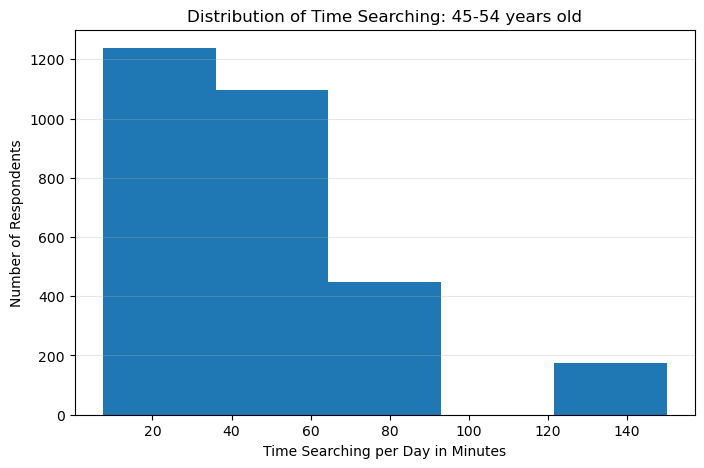

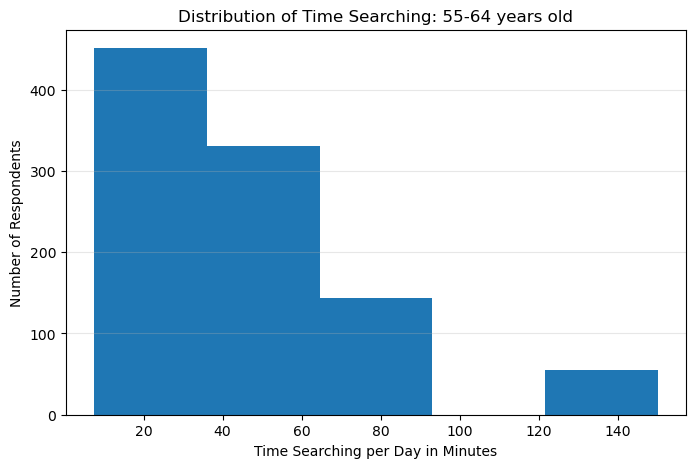

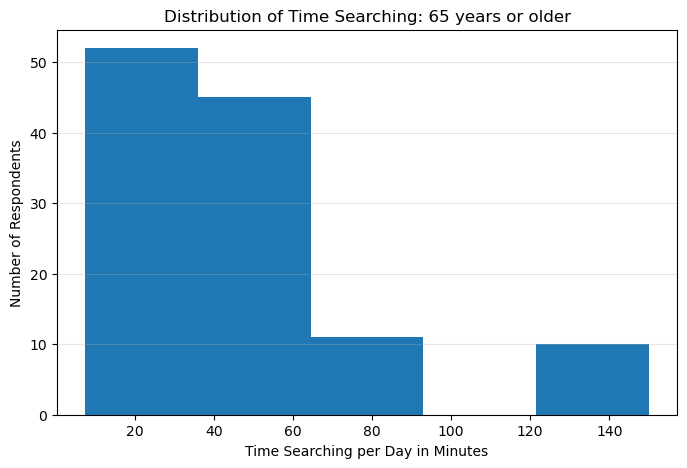

In [15]:
time_searching_mapping = {
    'Less than 15 minutes a day': 7.5,
    '15-30 minutes a day': 22.5,
    '30-60 minutes a day': 45,
    '60-120 minutes a day': 90,
    'Over 120 minutes a day': 150
}

df['TimeSearching_Numeric'] = df['TimeSearching'].map(time_searching_mapping)

df_time = df[['Age', 'TimeSearching_Numeric']].dropna()

age_order = [
    'Under 18 years old',
    '18-24 years old',
    '25-34 years old',
    '35-44 years old',
    '45-54 years old',
    '55-64 years old',
    '65 years or older'
]

for age_group in age_order:
    age_data = df_time[df_time['Age'] == age_group]['TimeSearching_Numeric']
    
    if len(age_data) > 0:
        plt.figure(figsize=(8, 5))
        plt.hist(age_data, bins=5)
        plt.title(f'Distribution of Time Searching: {age_group}')
        plt.xlabel('Time Searching per Day in Minutes')
        plt.ylabel('Number of Respondents')
        plt.grid(axis='y', alpha=0.3)
        plt.show()

### 3. Visualizing the Composition of Data


**3.1 Histogram of Most Desired Databases (`DatabaseWantToWorkWith`)**


Objective: Visualize the most desired databases for future learning using a histogram of the top 5 databases.


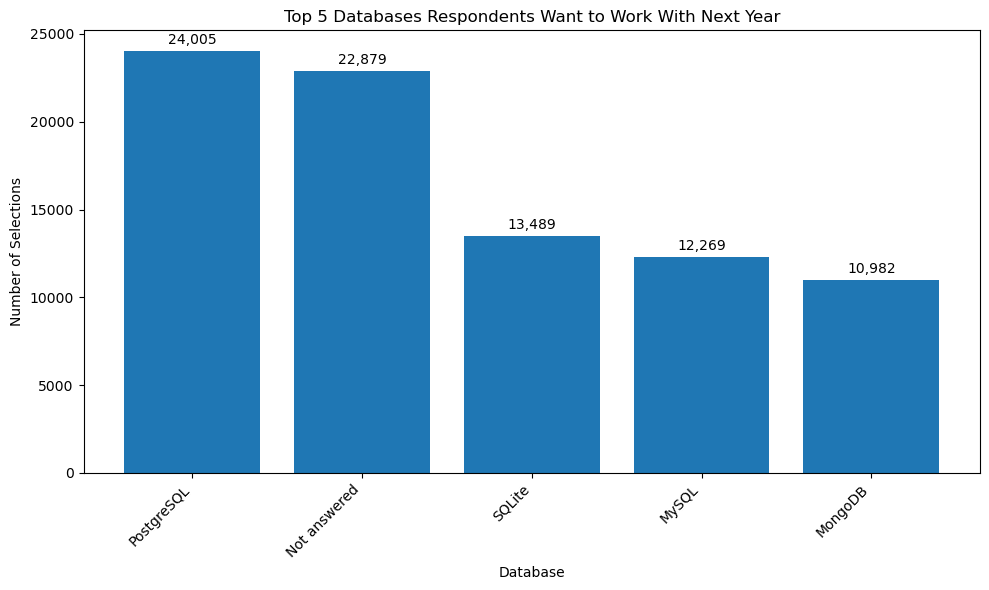

In [16]:
database_data = df["DatabaseWantToWorkWith"].fillna("Not answered")

database_list = (database_data.str.split(";").explode().str.strip())

# Count each database and select the top five
top_5_databases = database_list.value_counts().head(5)

plt.figure(figsize=(10, 6))

bars = plt.bar(
    top_5_databases.index,
    top_5_databases.values
)

plt.title("Top 5 Databases Respondents Want to Work With Next Year")
plt.xlabel("Database")
plt.ylabel("Number of Selections")
plt.xticks(rotation=45, ha="right")

plt.bar_label(
    bars,
    labels=[f"{value:,}" for value in top_5_databases.values],
    padding=3
)

plt.tight_layout()
plt.show()

**3.2 Histogram of Preferred Work Locations (`RemoteWork`)**


Objective: Use a histogram to explore the distribution of preferred work arrangements (`remote work`).


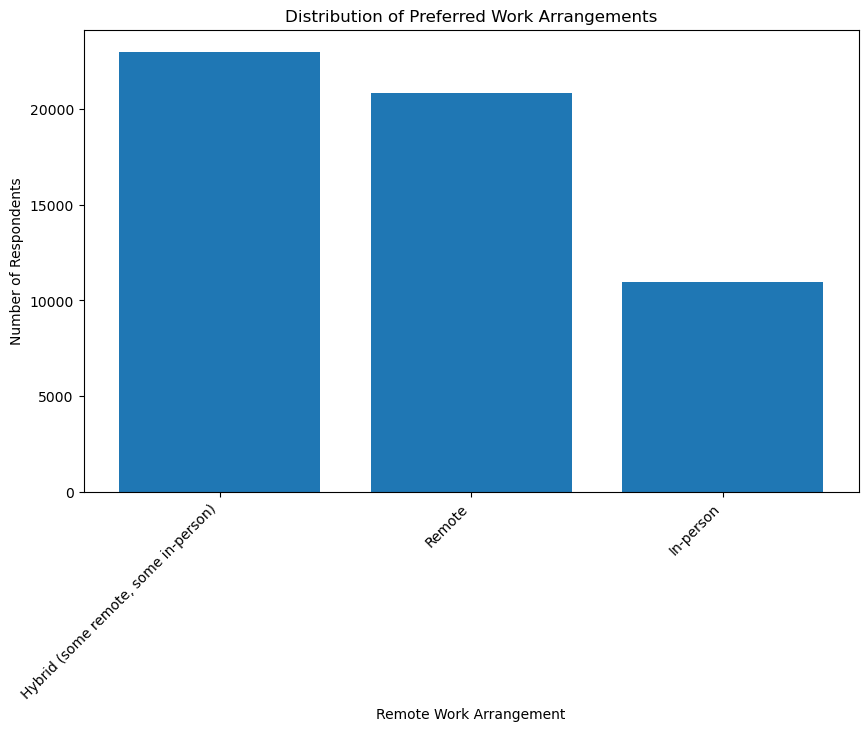

In [17]:
# Count each remote work category
remote_work_counts = df['RemoteWork'].value_counts()

# Plot histogram-style bar chart
plt.figure(figsize=(10, 6))

plt.bar(
    remote_work_counts.index,
    remote_work_counts.values
)

plt.title('Distribution of Preferred Work Arrangements')
plt.xlabel('Remote Work Arrangement')
plt.ylabel('Number of Respondents')
plt.xticks(rotation=45, ha='right')

plt.show()

### 4. Visualizing Comparison of Data


**4.1 Histogram of Median CompTotal for Ages 45 to 60**


Objective: Plot the histogram for `CompTotal` within the age group 45 to 60 to analyze compensation distribution among mid-career respondents.


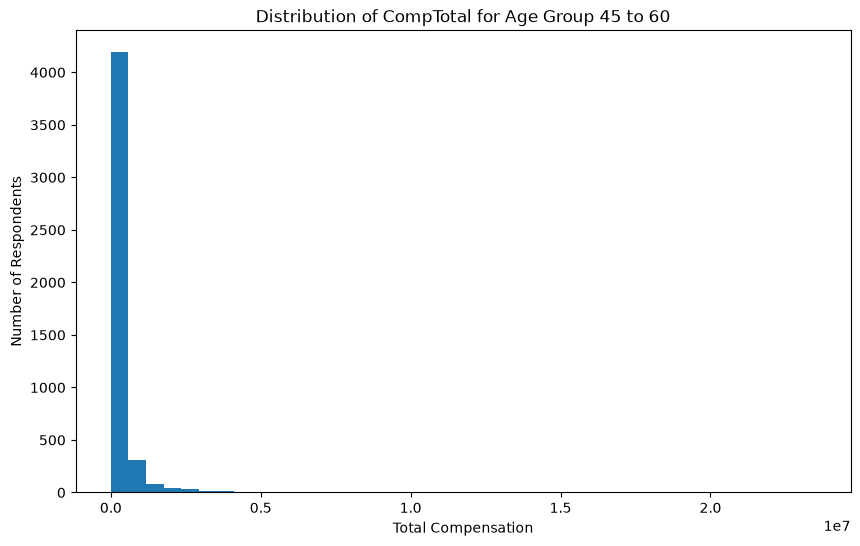

In [17]:
# Convert CompTotal to numeric
df['CompTotal'] = pd.to_numeric(df['CompTotal'], errors='coerce')

# Filter for age group 45 to 60
# Dataset has age ranges, so we use the closest available groups:
# 45-54 years old and 55-64 years old
age_45_60 = df[df['Age'].isin(['45-54 years old', '55-64 years old'])]

# Remove missing CompTotal values
comp_45_60 = age_45_60['CompTotal'].dropna()

# Remove extreme outliers using 99th percentile
upper_limit = comp_45_60.quantile(0.99)
comp_45_60_filtered = comp_45_60[comp_45_60 <= upper_limit]

# Plot histogram
plt.figure(figsize=(10, 6))

plt.hist(comp_45_60_filtered, bins=40)

plt.title('Distribution of CompTotal for Age Group 45 to 60')
plt.xlabel('Total Compensation')
plt.ylabel('Number of Respondents')

plt.show()

**4.2 Histogram of Job Satisfaction (`JobSat`) by YearsCodePro**


Objective: Plot the histogram for `JobSat` scores based on respondents' years of professional coding experience.


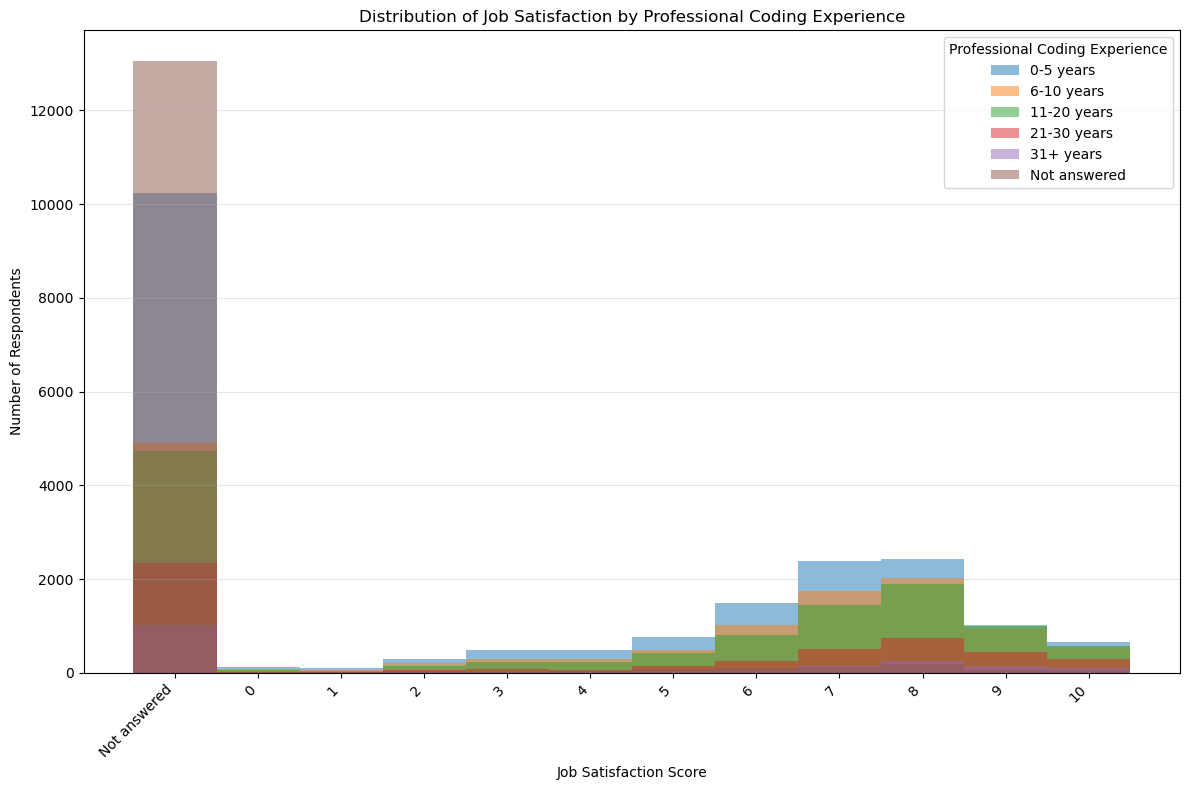

In [21]:
import numpy as np

# Convert YearsCodePro to numeric
df["YearsCodePro_Numeric"] = df["YearsCodePro"].replace({
    "Less than 1 year": 0,
    "More than 50 years": 51
})

df["YearsCodePro_Numeric"] = pd.to_numeric(
    df["YearsCodePro_Numeric"],
    errors="coerce"
)

# Convert JobSat to numeric
df["JobSat"] = pd.to_numeric(
    df["JobSat"],
    errors="coerce"
)

# Keep all rows—no dropna()
df_jobsat = df[
    ["YearsCodePro_Numeric", "JobSat"]
].copy()

# Create coding-experience groups
df_jobsat["Experience_Group"] = pd.cut(
    df_jobsat["YearsCodePro_Numeric"],
    bins=[0, 5, 10, 20, 30, np.inf],
    labels=[
        "0-5 years",
        "6-10 years",
        "11-20 years",
        "21-30 years",
        "31+ years"
    ],
    include_lowest=True
)

# Retain missing experience values as a category
df_jobsat["Experience_Group"] = (
    df_jobsat["Experience_Group"]
    .astype("object")
    .fillna("Not answered")
)

# Retain missing JobSat values using -1 as a plotting position
df_jobsat["JobSat_Plot"] = df_jobsat["JobSat"].fillna(-1)

plt.figure(figsize=(12, 8))

experience_order = [
    "0-5 years",
    "6-10 years",
    "11-20 years",
    "21-30 years",
    "31+ years",
    "Not answered"
]

# -1 represents missing JobSat; 0–10 are actual satisfaction scores
bins = np.arange(-1.5, 11.5, 1)

for group in experience_order:
    group_data = df_jobsat.loc[
        df_jobsat["Experience_Group"] == group,
        "JobSat_Plot"
    ]

    plt.hist(
        group_data,
        bins=bins,
        alpha=0.5,
        label=group
    )

plt.title(
    "Distribution of Job Satisfaction by Professional Coding Experience"
)
plt.xlabel("Job Satisfaction Score")
plt.ylabel("Number of Respondents")

plt.xticks(
    ticks=range(-1, 11),
    labels=["Not answered"] + list(range(0, 11)),
    rotation=45,
    ha="right"
)

plt.legend(
    title="Professional Coding Experience"
)

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### Final step: Close the database connection


Once you've completed the lab, make sure to close the connection to the SQLite database:



In [22]:
conn.close()

### Summary


In this lab, you used histograms to visualize various aspects of the dataset, focusing on:

- Distribution of compensation, coding experience, and work hours.

- Relationships in compensation across age groups and work status.

- Composition of data by desired databases and work environments.

- Comparisons of job satisfaction across years of experience.

Histograms helped reveal patterns and distributions in the data, enhancing your understanding of developer demographics and preferences.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
